**Dataset:** `data/placement_predict_50k Dataset_final.csv` (50,000 students).

The original 14-row teaching CSV is replaced by the 50k dataset, mapped as: `StudentID`→`ID`, `CGPA`→`CGPA`, `Internships`→`Internships`, `HistoryOfBacklogs`→`Backlogs`, `AptitudeTestScore`→`Aptitude` (missing values filled with the median), `PlacementStatus`→`Placed` (1=Yes, 0=No). The remarks about '14 students' therefore no longer apply: with 50,000 rows the numbers are meaningful. The plotted trees show only the top 3 levels.

# Practical 7: Random Forests, OOB Error, Bagging and Feature Subsampling

## Student Placement Prediction

### Aim
Implement and analyse Random Forests using **training and validation data**, study **OOB error convergence**, compare `max_features`, demonstrate **manual bootstrap bagging**, calculate **permutation importance**, and compare a Random Forest with a single Decision Tree.

### Key points
- **Decision Tree:** one person makes the decision.
- **Bagging:** ask many trees, each trained on a different bootstrap sample.
- **Random Forest:** many trees + bootstrap samples + random feature selection.
- **OOB:** students left out of a tree's bootstrap sample can help evaluate that tree.
- **Permutation importance:** shuffle one feature and see how much model accuracy changes.

### CSV
This notebook uses `data/placement_predict_50k Dataset_final.csv`, mapped to the columns `ID, CGPA, Internships, Backlogs, Aptitude, Placed` (see the note above).

> With 50,000 students the numerical results are stable enough to interpret.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)


In [2]:
# ============================================================
# 2. LOAD CSV DATASET
# ============================================================

CSV_PATH = "/Users/divyasaisomana/placement prediction system/data/placement_predict_50k Dataset_final.csv"

raw = pd.read_csv(CSV_PATH)

# Map the 50k dataset onto the columns this notebook works with: ID, CGPA, Internships, Backlogs, Aptitude, Placed
df = pd.DataFrame({
    "ID": raw["StudentID"],
    "CGPA": raw["CGPA"],
    "Internships": raw["Internships"],
    "Backlogs": raw["HistoryOfBacklogs"],
    "Aptitude": raw["AptitudeTestScore"].fillna(raw["AptitudeTestScore"].median()),
    "Placed": raw["PlacementStatus"].map({0: "No", 1: "Yes"})
})

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (50000, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,1,6.29,1,No,66.7,No
1,2,5.23,0,Yes,48.2,No
2,3,5.52,1,No,73.8,Yes
3,4,7.51,1,No,69.8,Yes
4,5,8.65,2,No,73.1,Yes


In [3]:
    # ============================================================
    # 4. DATA PREPROCESSING
    # ============================================================

    # Create a copy so that the original dataset remains unchanged.
    data_model = df.copy()

    # ID is only an identifier and should not be used for training.
    data_model = data_model.drop(columns=["ID"])

    # Convert Yes/No values to 1/0.
  
    mapping = {"no": 0, "yes": 1}
    for col in ["Backlogs", "Placed"]:
        data_model[col] = data_model[col].astype(str).str.strip().str.lower().map(mapping)


    # Check the result. 
    print("Preprocessed dataset:")
    display(data_model)

    print("\nData types:")
    print(data_model.dtypes)


Preprocessed dataset:


,CGPA,Internships,Backlogs,Aptitude,Placed
0,6.29,1,0,66.7,0
1,5.23,0,1,48.2,0
2,5.52,1,0,73.8,1
3,7.51,1,0,69.8,1
4,8.65,2,0,73.1,1
...,...,...,...,...,...
49995,8.27,1,0,75.8,1
49996,5.95,2,0,81.4,1
49997,5.92,1,1,69.9,0
49998,6.09,0,0,74.5,0



Data types:
CGPA           float64
Internships      int64
Backlogs         int64
Aptitude       float64
Placed           int64
dtype: object


In [4]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["Placed"])
y = data_model["Placed"]

print("Features:", X.columns.tolist())
print("Target: Placed")


Features: ['CGPA', 'Internships', 'Backlogs', 'Aptitude']
Target: Placed


In [5]:
X

,CGPA,Internships,Backlogs,Aptitude
0,6.29,1,0,66.7
1,5.23,0,1,48.2
2,5.52,1,0,73.8
3,7.51,1,0,69.8
4,8.65,2,0,73.1
...,...,...,...,...
49995,8.27,1,0,75.8
49996,5.95,2,0,81.4
49997,5.92,1,1,69.9
49998,6.09,0,0,74.5


## Step 1 — Training Data and Validation/Test Data

Think of it simply:

- **Training data:** the students the model learns from.
- **Validation/test data:** students kept aside to check performance on unseen data.

We use the same split throughout this practical so the models are compared fairly.


In [6]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


Training samples: 35000
Validation samples: 15000

Training class distribution:
Placed
1    22999
0    12001
Name: count, dtype: int64

Validation class distribution:
Placed
1    9857
0    5143
Name: count, dtype: int64


# Part A — Single Decision Tree Baseline

First build one Decision Tree. This is our baseline.

Then we will build a Random Forest and ask:

**Does many trees work better than one tree?**


In [7]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
        criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")


SINGLE DECISION TREE
Training Accuracy   : 0.9914
Validation Accuracy : 0.8653
Tree Depth          : 48
Number of Leaves    : 4489


# Part B — Random Forest

A Random Forest creates many Decision Trees.

Important parameters:

- `n_estimators` → number of trees.
- `bootstrap=True` → each tree gets a bootstrap sample.
- `oob_score=True` → calculate Out-of-Bag accuracy.
- `max_features` → random feature subsampling at each split.


In [8]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")


RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 0.9914
Validation Accuracy : 0.8853
OOB Accuracy        : 0.8869
OOB Error           : 0.1131


In [9]:
len(rf.estimators_)

100

In [10]:
print(rf.estimators_[0])

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


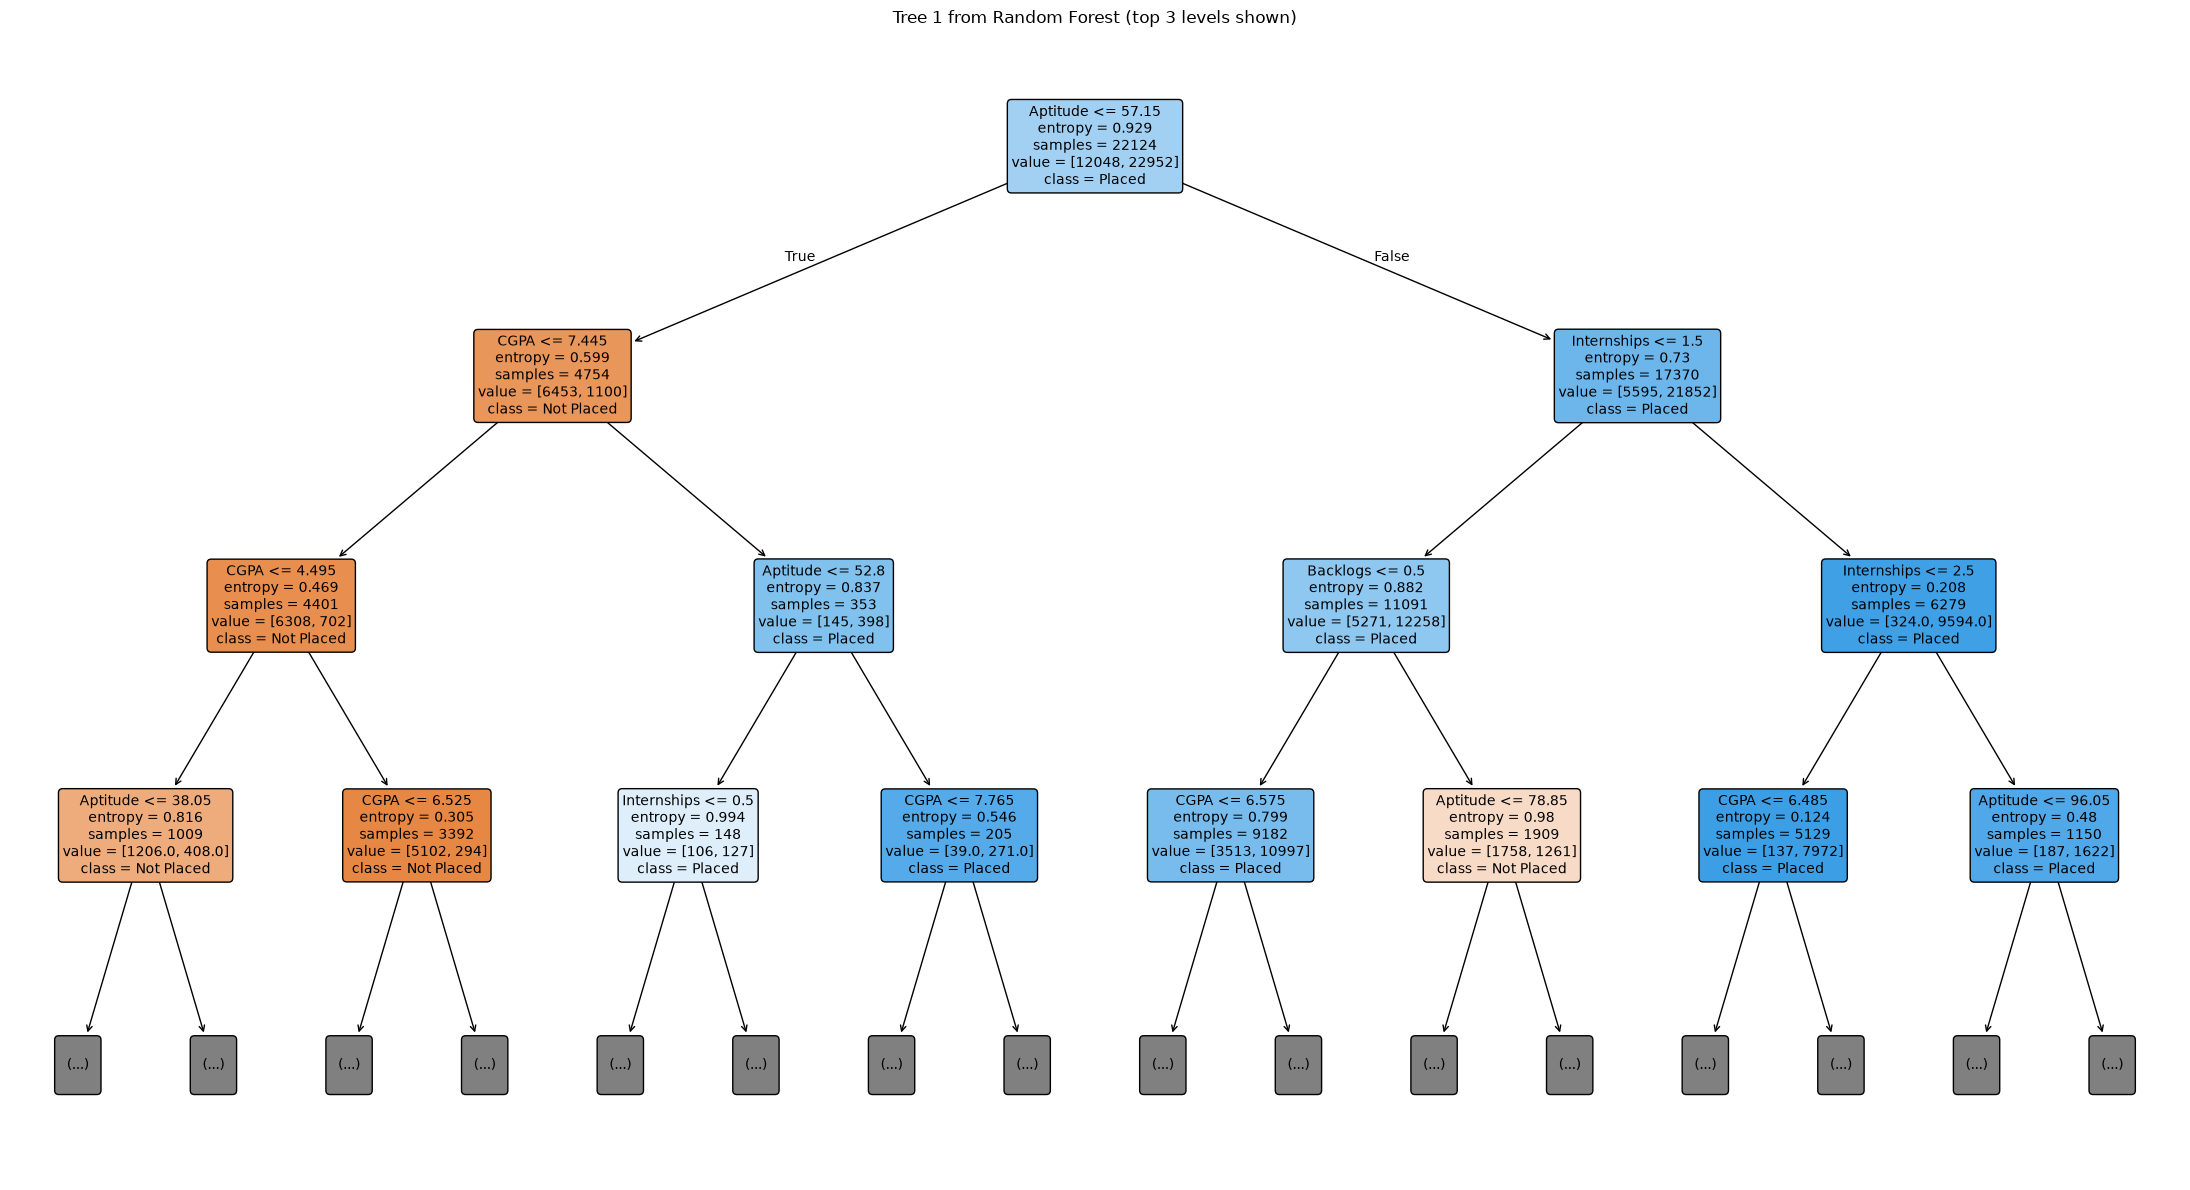

In [11]:
# ============================================================
# IMPORT plot_tree
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Tree 1 from Random Forest (top 3 levels shown)")
plt.tight_layout()
plt.show()

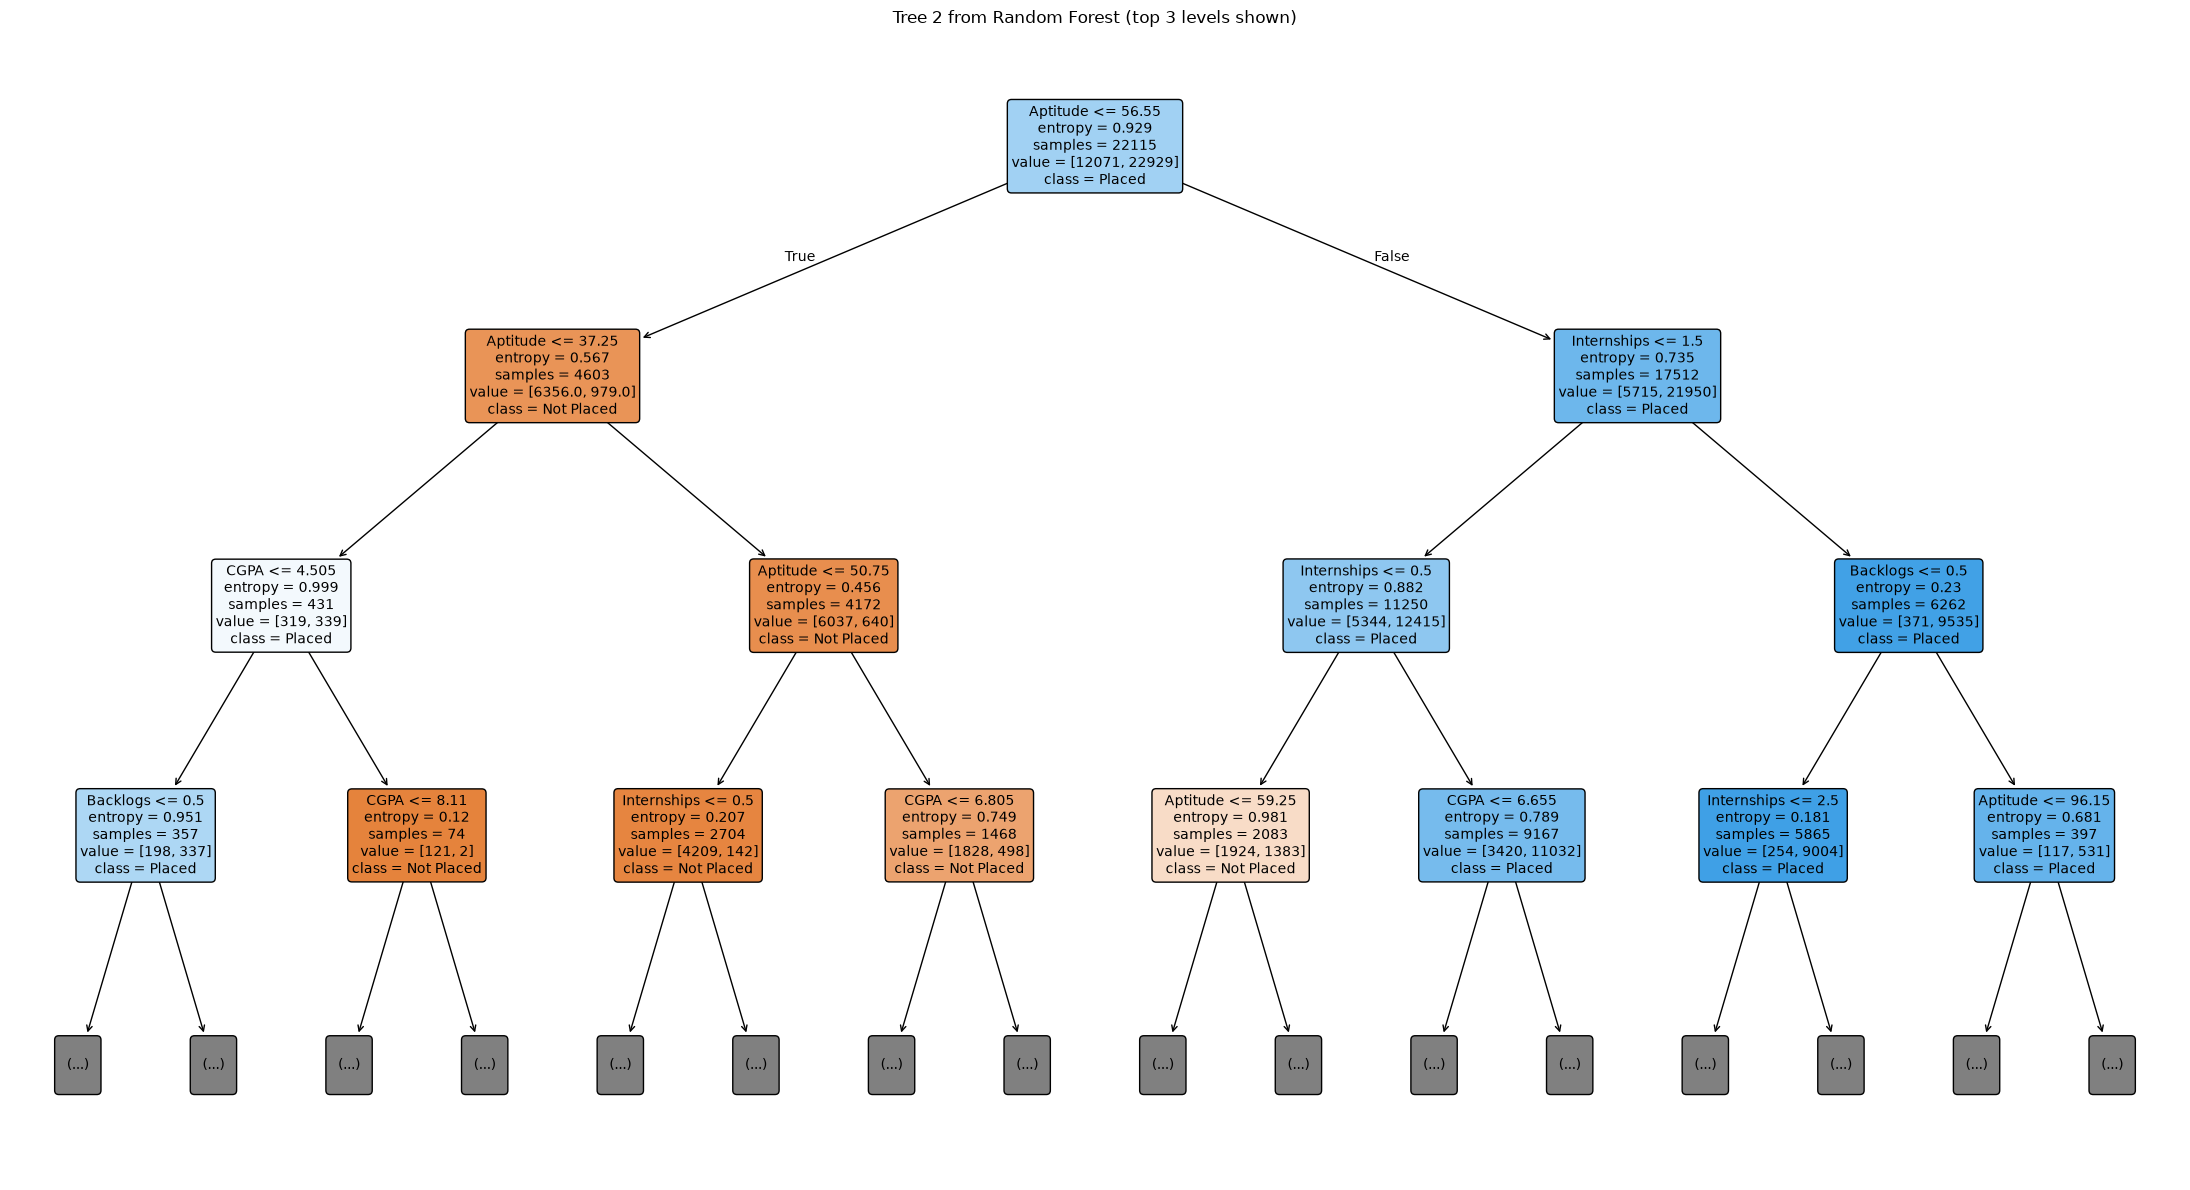

In [12]:
plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Tree 2 from Random Forest (top 3 levels shown)")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["Not Placed", "Placed"],
    zero_division=0
))


              precision    recall  f1-score   support

  Not Placed       0.84      0.82      0.83      5143
      Placed       0.91      0.92      0.91      9857

    accuracy                           0.89     15000
   macro avg       0.87      0.87      0.87     15000
weighted avg       0.88      0.89      0.88     15000



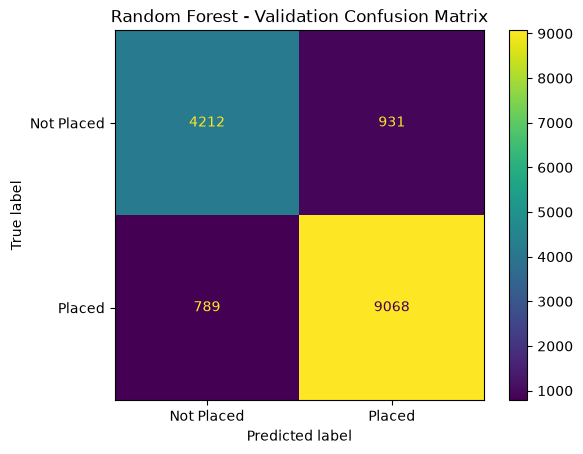

In [14]:
# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()


# Part C — OOB Error Convergence

For each tree, some training observations are not selected in its bootstrap sample. These are **Out-of-Bag (OOB)** observations for that tree.

As more trees are added, the OOB estimate usually becomes more stable.

We record OOB accuracy and OOB error for different numbers of trees.


In [15]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))


/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.5367,0.4633
1,5,0.8181,0.1819
2,10,0.8711,0.1289
3,20,0.8820,0.1180
4,30,0.8846,0.1154
5,50,0.8853,0.1147
6,75,0.8864,0.1136
7,100,0.8869,0.1131
8,150,0.8866,0.1134
9,200,0.8869,0.1131


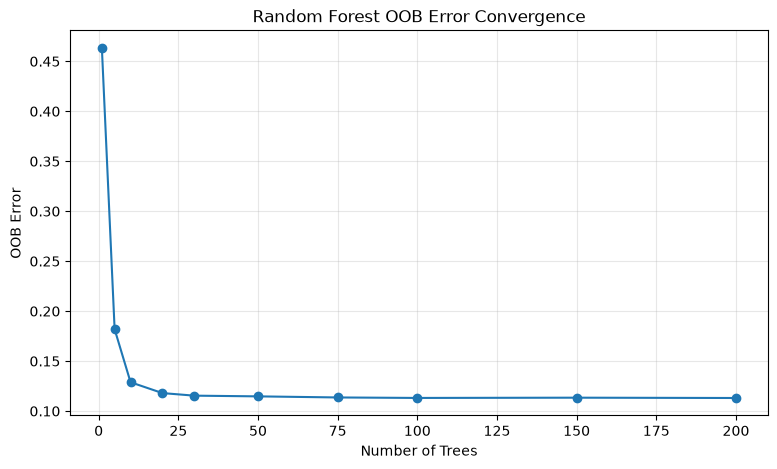

In [16]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()


### Student observation
Look for the region where OOB error becomes relatively stable.

With 50,000 students the OOB curve is much smoother than it would be on a tiny teaching dataset; some jumpiness for very small numbers of trees is still expected.


# Part D — `max_features` Comparison

`max_features` controls how many features are considered when a tree searches for a split.

We compare:

- `sqrt`
- `log2`
- `None` → all features

This demonstrates **feature subsampling**.


In [17]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,0.9914,0.8853,0.8869,0.1131
1,log2,0.9914,0.8853,0.8869,0.1131
2,None,0.9914,0.8830,0.8837,0.1163


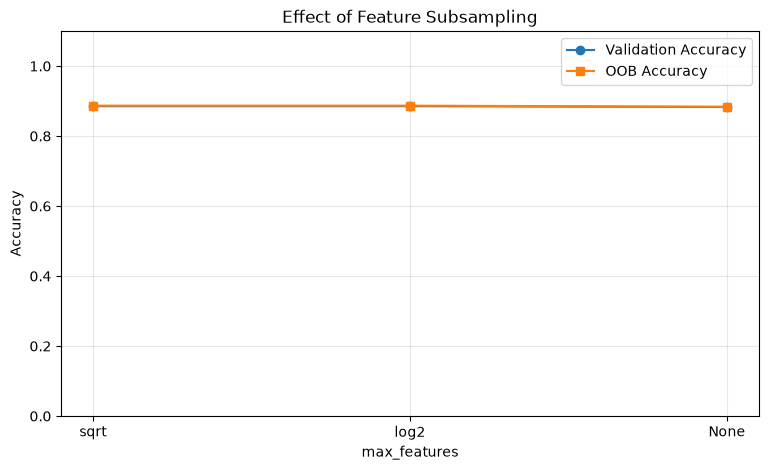

In [18]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


# Part E — Manual Bootstrap Bagging

### Layman idea

Suppose the training set has students:

`S1, S2, S3, S4, ...`

For one tree we randomly select students **with replacement**.

A bootstrap sample might look like:

`S1, S3, S3, S5, S7, S1, ...`

Another tree receives a different sample.

This section manually demonstrates the idea before using scikit-learn's BaggingClassifier.


In [19]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))


Bootstrap indices:
[ 3123 27088 22910 ...  3764  2212  8513]

Unique selected rows:
[    0     1     4 ... 34996 34998 34999]

OOB row indices:
[    2     3     5 ... 34992 34994 34997]

Total bootstrap observations: 35000
Unique observations: 22110
OOB observations: 12890


In [20]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")


50 manually bagged trees trained.


In [21]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation students.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees.
manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)


Manual Bootstrap Bagging Validation Accuracy: 0.8811


# Part F — scikit-learn BaggingClassifier

The previous cells showed the mechanism manually.

Now `BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

**Bagging vs Random Forest:**
- Bagging mainly uses bootstrap samples.
- Random Forest additionally introduces random feature selection at splits.


In [22]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")


BAGGING PERFORMANCE
Training Accuracy   : 0.9914
Validation Accuracy : 0.8831


# Part G — Permutation Importance

### Layman idea

1. Measure normal validation accuracy.
2. Shuffle one feature.
3. Predict again.
4. If accuracy drops a lot, that feature was important.
5. If accuracy changes little, that feature contributed less.

We calculate it on the validation set.


In [23]:
# ============================================================
# 19. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))


,Feature,Mean_Importance,Std_Importance
0,CGPA,0.1633,0.0028
1,Internships,0.0450,0.0017
2,Aptitude,0.0398,0.0021
3,Backlogs,0.0179,0.0012


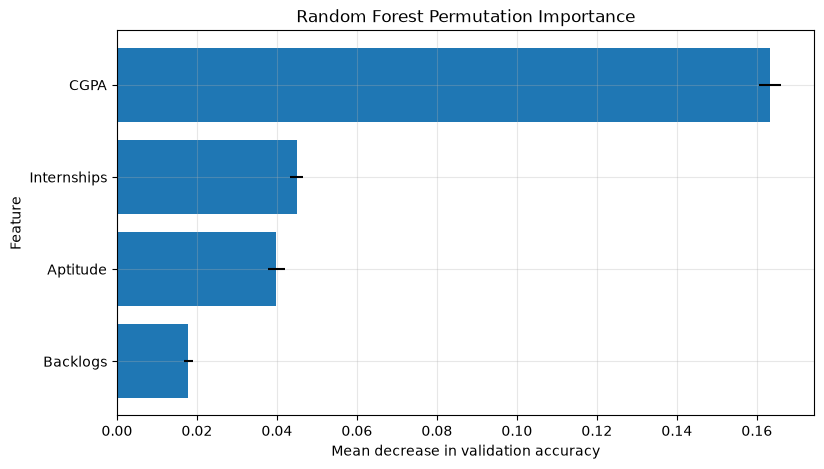

In [24]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()


# Part H — `rf_vs_single_tree()` Function

This is the main reusable experiment.

The function receives:

`X_train, y_train, X_val, y_val, n_estimators_list`

and returns:

`[n_estimators, RF_val_acc, DT_val_acc, OOB_acc]`

It also plots the requested **three lines**.


In [25]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df


/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


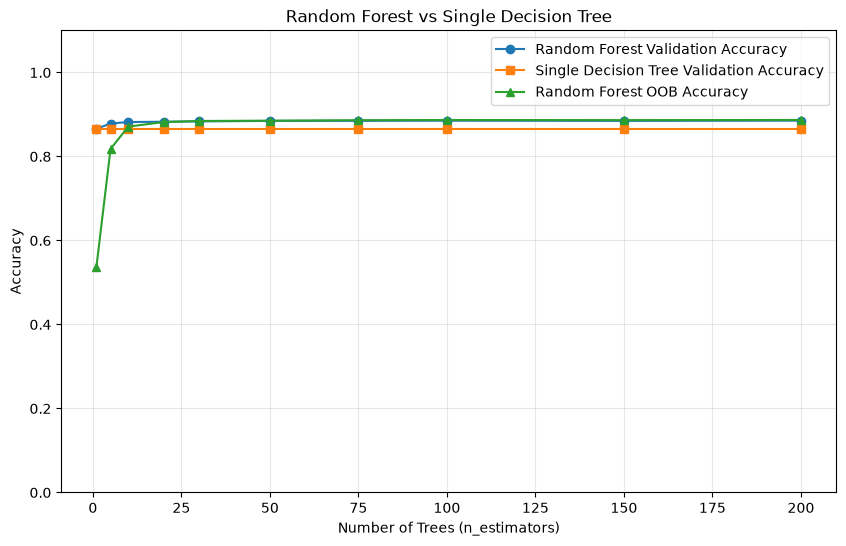

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8659,0.8653,0.5367
1,5,0.8785,0.8653,0.8181
2,10,0.8821,0.8653,0.8711
3,20,0.8827,0.8653,0.8820
4,30,0.8836,0.8653,0.8846
5,50,0.8847,0.8653,0.8853
6,75,0.8850,0.8653,0.8864
7,100,0.8853,0.8653,0.8869
8,150,0.8849,0.8653,0.8866
9,200,0.8854,0.8653,0.8869


In [26]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [27]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())


Best Random Forest result based on validation accuracy:
n_estimators    200.000000
RF_val_acc        0.885400
DT_val_acc        0.865267
OOB_acc           0.886914


# Part I — Overall Model Comparison

In [28]:
# ============================================================
# 24. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        np.nan,
        accuracy_score(y_train, bagging_train_pred)
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, dt_val_pred),
        accuracy_score(y_val, rf_val_pred),
        manual_bagging_acc,
        accuracy_score(y_val, bagging_val_pred)
    ],
    "OOB Accuracy": [
        np.nan,
        rf.oob_score_,
        np.nan,
        np.nan
    ]
})

display(overall_comparison.round(4))


,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,0.9914,0.8653,NaN
1,Random Forest,0.9914,0.8853,0.8869
2,Manual Bootstrap Bagging,NaN,0.8811,NaN
3,BaggingClassifier,0.9914,0.8831,NaN


# Final Learning Summary

Students should be able to explain:

1. How Random Forest combines many Decision Trees.
2. How bootstrap sampling creates different training sets.
3. What OOB observations are.
4. How OOB error changes as the number of trees increases.
5. What `max_features` means.
6. Why feature subsampling makes trees different.
7. How manual bagging works.
8. How permutation importance identifies influential features.
9. Whether Random Forest improves over a single Decision Tree on the validation data.
10. Why results from a single train/validation split should be interpreted with some caution.
